## Introduction: Telecommunication Data Preparation and Initial Data Exploration

Purpose: Prepare unmodified ATS customer dataset to meet Stage 2 deliverable, and handing off processed dataset for further analysis for Data Analyst. This notebook also serves as a reference for preliminary insights

Key deliverable:
- Clean and scaled dataset ready for classification and regression analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load the Dataset
In this step, Telco Customer Churn dataset will be loaded into a Pandas dataframe through `pd.read_csv()` function. The dataset was sourced through Kaggle as part of ACS WIL Data Analytic Internship. Loading the dataset into a DataFrame allows for a more efficient data exploration, preprocessing, analysis, and serves as the base model for further model development.

In [2]:
df = pd.read_csv("/Users/dan/PycharmProjects/JupyterProject/data/preprocessed/Dataset_ATS_v2.csv")

## 2. Preliminary Data Exploration
Before building any machine learning model, it is critical to understand the structure and the quality of the dataset. This preliminary exploration provides a brief overview of the data and helps identify whether further preprocessing are required:
The following methods are used:
- `df.head()` - to inspect the first five rows of the dataset which provide a snapshot of the column names, data format, and values
- `df.shape` - to inspect the size of the dataset including total number of rows and columns
- `df.info()` - to get a summary of the data types and missing values present in the dataset
- `df.describe()` - to get a statistical summary of the numerical and categorical features of the dataset

In [3]:
df.head()

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes
1,Male,0,No,41,Yes,No,DSL,One year,25,No
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No


In [4]:
df.shape

(7043, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gender           7043 non-null   object
 1   SeniorCitizen    7043 non-null   int64 
 2   Dependents       7043 non-null   object
 3   tenure           7043 non-null   int64 
 4   PhoneService     7043 non-null   object
 5   MultipleLines    7043 non-null   object
 6   InternetService  7043 non-null   object
 7   Contract         7043 non-null   object
 8   MonthlyCharges   7043 non-null   int64 
 9   Churn            7043 non-null   object
dtypes: int64(3), object(7)
memory usage: 550.4+ KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
tenure,7043.0,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
MonthlyCharges,7043.0,64.758768,30.091650,18.0,36.0,70.0,90.0,119.0


In [7]:
df.isnull().sum()

gender             0
SeniorCitizen      0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
Contract           0
MonthlyCharges     0
Churn              0
dtype: int64

Since there are no missing values, we can assume the data quality is complete and is safe for further data inspection. Next, we will be inspecting numerical features.

## 3. Inspecting and Fixing Data Types

In this step, Data types will be inspected based on business logic rules:
- It appears `tenure` has values that ranges from 0 to 72 months, meaning a wide range spread is observed. This feature might be a good predictor. However, billing months are usually stored as whole numbers, so it might be better to round the values as `.astype(int)`.
- Similarly, `MonthlyCharges` has values that are in the range of 18 to 119 and might be a good predictor candidate. Charges amount may vary depending on the service and plan, and is likely to be a continuous variable. Therefore, we will be converting this feature as `.astype(float)`
- `SeniorCitizen` has a mean of 0.162147 meaning out of all data in the dataset, Senior Citizen accounts for 16% of customers. It is already a binary value and we will keep it as `.astype(int)`
- The other 7 columns are object type (categorical values) and potentially need to be converted into binary values (encoded)

In [8]:
df['tenure']         = df['tenure'].astype(int)
df['MonthlyCharges'] = df['MonthlyCharges'].astype(float)
df['SeniorCitizen']  = df['SeniorCitizen'].astype(int)

print("Data types after fixing:")
print(df.dtypes)

Data types after fixing:
gender              object
SeniorCitizen        int64
Dependents          object
tenure               int64
PhoneService        object
MultipleLines       object
InternetService     object
Contract            object
MonthlyCharges     float64
Churn               object
dtype: object


### 4.1. Encode Binary Columns

In [9]:
binary_cols = ['Dependents', 'PhoneService', 'MultipleLines', 'Churn']

for col in binary_cols:
    if df[col].dtype == object:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

print("Binary columns encoded (Yes=1, No=0):")
for col in binary_cols:
    print(f"  {col}: {sorted(df[col].unique().tolist())}")

Binary columns encoded (Yes=1, No=0):
  Dependents: [0, 1]
  PhoneService: [0, 1]
  MultipleLines: [0, 1]
  Churn: [0, 1]


## 4.2. Encode Gender (Female/Male → 0/1)

In [10]:
if df['gender'].dtype == object:
    df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

print(f"gender encoded: {sorted(df['gender'].unique().tolist())} (0=Female, 1=Male)")

gender encoded: [0, 1] (0=Female, 1=Male)


## 4.3. Encode Contract Type (Ordinal Encoding)

`Contract` has three values with a natural order and we would like to preserve the order. Therefore, we will encode the values as:
- `Month-to-month` → weakest commitment → `0`
- `One year`       → medium commitment  → `1`
- `Two year`       → strongest commitment → `2`

If we don't use Ordinal Encoding, we will lose the information that "Two year" > "One year" > "Month-to-month".

In [11]:
contract_order = {
    'Month-to-month': 0,
    'One year':       1,
    'Two year':       2
}
if df['Contract'].dtype == object:
    df['Contract'] = df['Contract'].map(contract_order)

print("Contract encoded (ordinal):")
print(df['Contract'].value_counts().sort_index())

Contract encoded (ordinal):
Contract
0    3875
1    1473
2    1695
Name: count, dtype: int64


## 4.4. Encode Internet Service (One-Hot Encoding)

`InternetService` has two values: `DSL` and `Fiber optic` and they are just different types and is unordered categories. Therefore, converting them into one bonary column per category is ideal. We will also drop the `DSL` column as it is redundant with `internet_fiber`.

In [12]:
df = pd.get_dummies(df, columns=['InternetService'], drop_first=True)

# Rename the created column for clarity
df.rename(columns={'InternetService_Fiber optic': 'internet_fiber'}, inplace=True)

print("InternetService one-hot encoded → 'internet_fiber' column (1=Fiber, 0=DSL)")
print(f"  Columns now: {df.columns.tolist()}")

InternetService one-hot encoded → 'internet_fiber' column (1=Fiber, 0=DSL)
  Columns now: ['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'Contract', 'MonthlyCharges', 'Churn', 'internet_fiber']


## 5. Exploratory Data Analysis (EDA)

Now that the dataset is fully encoded and is in numeric values, we will explore relationships that will inform both the analyst's downstream work and scaling decisions:
- Inspecting `Churn` class balance that might affects  imbalance affects which metrics matter later (e.g. accuracy vs. recall)
- Inspecting the dataset distribution and shape of `tenure` and `MonthlyCharges` to check outliers
- How `tenure`, `MonthlyCharges`, and `Contract` relate to `Churn`
- Correlation matrix across all features to flag redundancy

Churn class balance:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


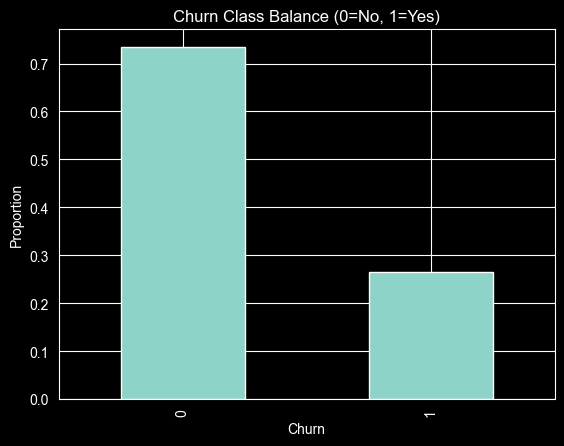

In [13]:
churn_rate = df['Churn'].value_counts(normalize=True)
print("Churn class balance:")
print(churn_rate)

churn_rate.plot(kind='bar', title='Churn Class Balance (0=No, 1=Yes)')
plt.ylabel('Proportion')
plt.show()

Based on the chart, it is proven `Churn` is imbalanced (~26.5% Yes vs ~73.5% No). Further scaling and class balancing are needed for modeling decision on further deliverable. However, upon inspecting the dataset, it is unlikely to perform undersampling due to the small dataset and is not likely enough sample should we cut the remaining unchurned. This will affect the overall prediction. Therefore, SMOTE sampling is likely the safer choice and should only ever be applied to the training set.

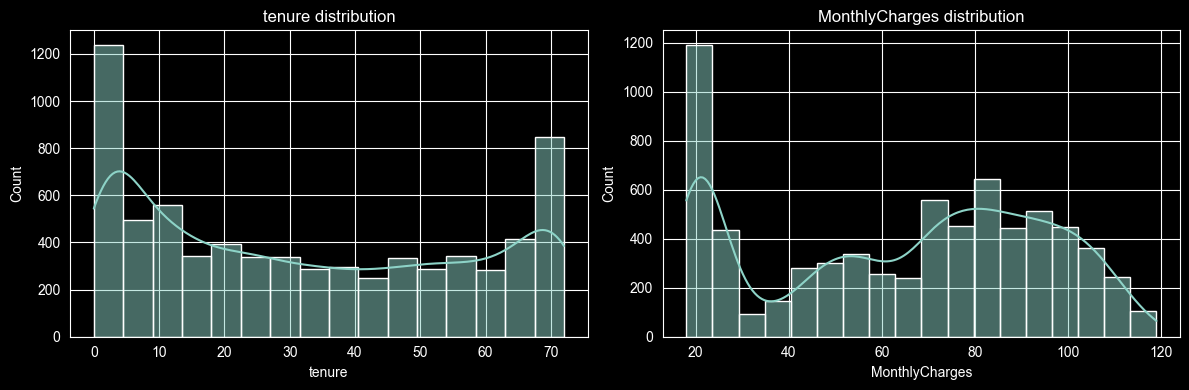

tenure skew: 0.24
MonthlyCharges skew: -0.22


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['tenure'], kde=True, ax=axes[0])
axes[0].set_title('tenure distribution')
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[1])
axes[1].set_title('MonthlyCharges distribution')
plt.tight_layout()
plt.show()

print("tenure skew:", df['tenure'].skew().round(2))
print("MonthlyCharges skew:", df['MonthlyCharges'].skew().round(2))

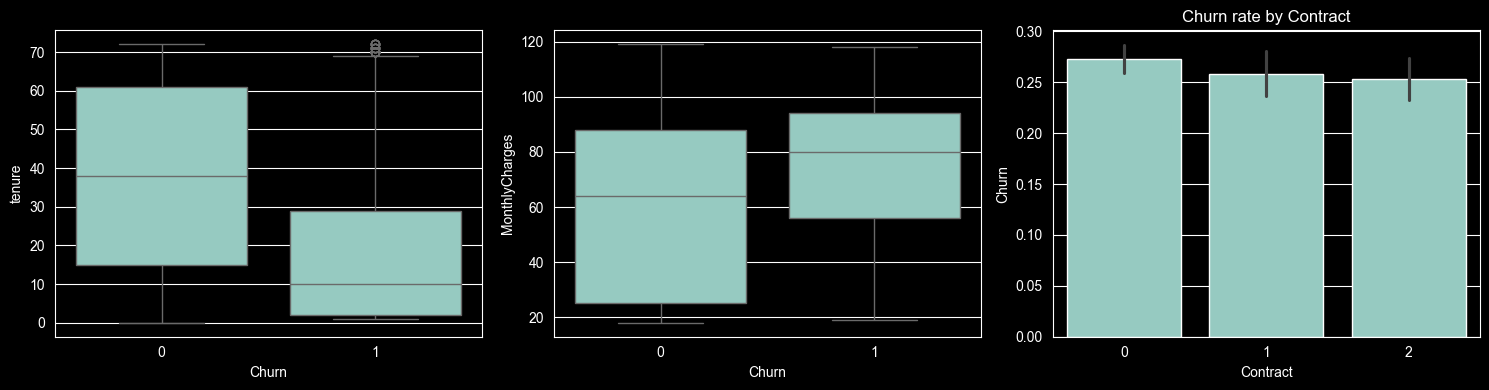

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0])
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1])
sns.barplot(x='Contract', y='Churn', data=df, ax=axes[2])
axes[2].set_title('Churn rate by Contract')
plt.tight_layout()
plt.show()

### 5.5 Churn Rate by Gender

From this point onwards, we will be inspecting the encoded categorical features using Boxplots to explore its meaningfulness to business logic/requirements

Churn rate by gender (0=Female, 1=Male):
gender
0    0.269
1    0.262
Name: Churn, dtype: float64


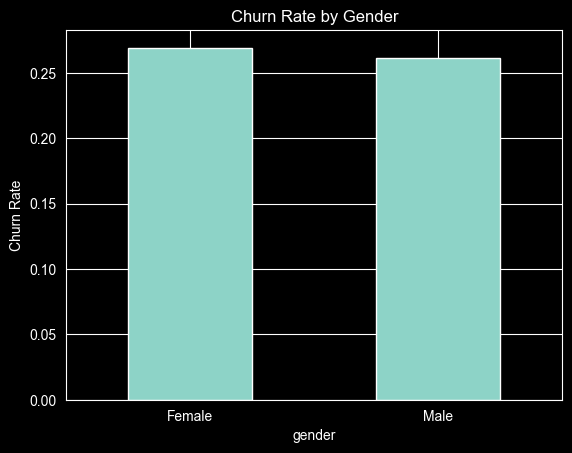

In [16]:
gender_churn = df.groupby('gender')['Churn'].mean()
print("Churn rate by gender (0=Female, 1=Male):")
print(gender_churn.round(3))

gender_churn.plot(kind='bar', title='Churn Rate by Gender')
plt.ylabel('Churn Rate')
plt.xticks([0, 1], ['Female', 'Male'], rotation=0)
plt.show()

Churn is ~27% for both Female (26.9%) and Male (26.2%) customers serves no meaningful difference towards Churn prediction so its likely Gender isn't a churn driver here, and it also isn't something the company could ethically target retention campaigns by.

### 5.6 Churn Rate by Dependents

Churn rate by Dependents (0=No, 1=Yes):
Dependents
0    0.313
1    0.155
Name: Churn, dtype: float64


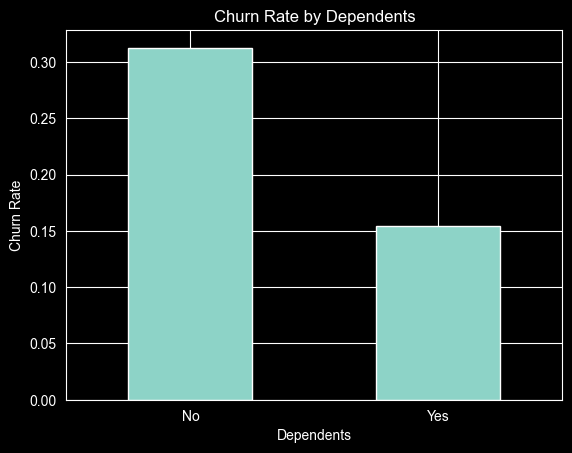

In [17]:
dependents_churn = df.groupby('Dependents')['Churn'].mean()
print("Churn rate by Dependents (0=No, 1=Yes):")
print(dependents_churn.round(3))

dependents_churn.plot(kind='bar', title='Churn Rate by Dependents')
plt.ylabel('Churn Rate')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.show()

Based on this chart, it is likely that customers with no dependents are more likely to churn (31.3%) than customers with dependents (15.5%). This mean there is a certain proxies for household stability for instance child-parents relationship. This might flag single customers as potential retention segment.

### 5.7 Churn Rate by Phone Service

Churn rate by PhoneService (0=No, 1=Yes):
PhoneService
0    0.249
1    0.267
Name: Churn, dtype: float64


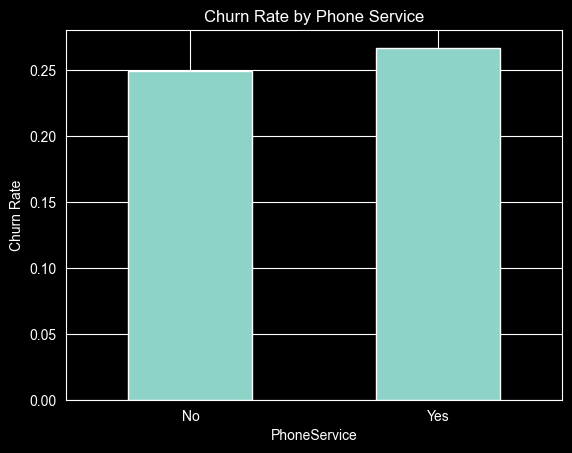

In [18]:
phone_churn = df.groupby('PhoneService')['Churn'].mean()
print("Churn rate by PhoneService (0=No, 1=Yes):")
print(phone_churn.round(3))

phone_churn.plot(kind='bar', title='Churn Rate by Phone Service')
plt.ylabel('Churn Rate')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.show()

It appears `PhoneService` has similar churn rate and is likely a weak signal for a prediction driver.

### 5.8 Churn Rate by Multiple Lines

Churn rate by MultipleLines (0=No, 1=Yes):
MultipleLines
0    0.265
1    0.265
Name: Churn, dtype: float64


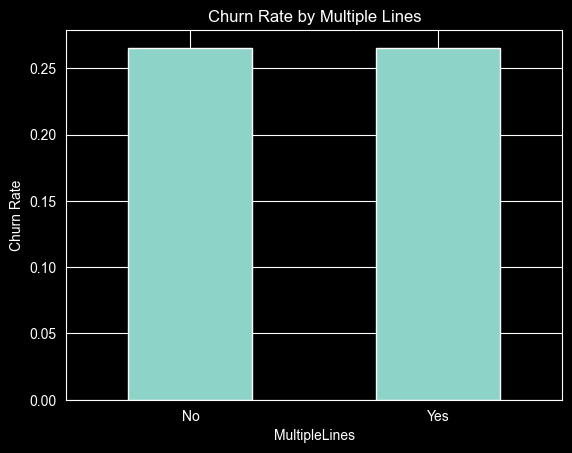

In [19]:
multiline_churn = df.groupby('MultipleLines')['Churn'].mean()
print("Churn rate by MultipleLines (0=No, 1=Yes):")
print(multiline_churn.round(3))

multiline_churn.plot(kind='bar', title='Churn Rate by Multiple Lines')
plt.ylabel('Churn Rate')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.show()

Identical churn rate 26.5% vs 26.5%, meaning customers with multiple lines has no meaningful impact on churn in this data

### 5.9 Churn Rate by Internet Service Type

Churn rate by internet_fiber (0=DSL, 1=Fiber optic):
internet_fiber
False    0.274
True     0.254
Name: Churn, dtype: float64


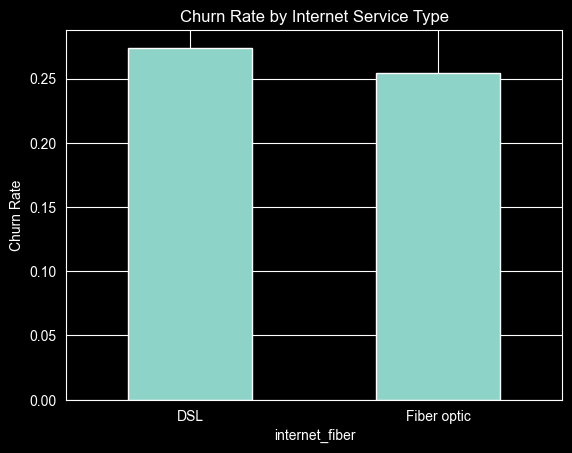

In [20]:
internet_churn = df.groupby('internet_fiber')['Churn'].mean()
print("Churn rate by internet_fiber (0=DSL, 1=Fiber optic):")
print(internet_churn.round(3))

internet_churn.plot(kind='bar', title='Churn Rate by Internet Service Type')
plt.ylabel('Churn Rate')
plt.xticks([0, 1], ['DSL', 'Fiber optic'], rotation=0)
plt.show()

DSL customers churn slightly more (27.4%) than Fiber optic customers (25.4%) is a modest gap, not dramatic on its own. Combined with Section 5.3's finding that `Contract` is the strongest categorical predictor, the overall picture for the company: contract length and household stability (dependents) matter far more to churn than which specific service the customer has (phone lines, internet type, gender). Retention efforts are better spent on contract upgrades and support for single/no-dependent customers than on service-type-specific interventions.

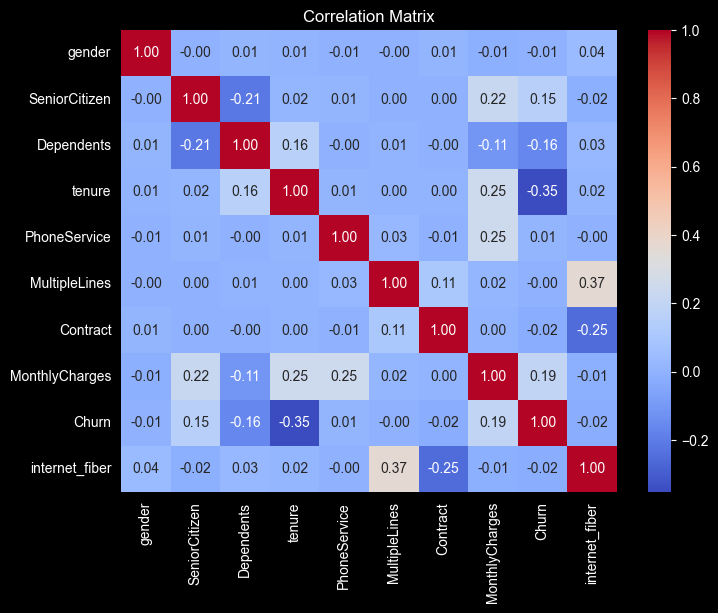

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

The Correlation Matrix shows:
- Strong relationship between `MultipleLines` and `internet_fiber` (0.37)
- High correlation coefficient between `tenure` and `MonthlyCharges` (0.25)

## 6. Feature Engineering

Following the business requirement document from our Business Analyst, we create three new features:
1. `TotalCharge` = `tenure*MonthlyCharges` : How much this customer has paid in total so far (CLV proxy)
2. `TenureGroup` = Bucket `tenure` into lifecycle stages (`0-12m`, `13-24m`, `25-48m`, `49-72m`) : to map out the Customer lifecycle stage
3. `HighValueCustomer` = Flag customers paying more than $80/month and is a revenue priority flag

In [22]:
# TotalCharges: how much this customer has paid in total so far (CLV proxy)
df['TotalCharges'] = df['tenure'] * df['MonthlyCharges']

# TenureGroup: bucket tenure (months) into lifecycle stages
tenure_bins = [0, 12, 24, 48, 72]
tenure_labels = ['0-12m', '13-24m', '25-48m', '49-72m']
df['TenureGroup'] = pd.cut(df['tenure'], bins=tenure_bins, labels=tenure_labels, include_lowest=True)

# HighValueCustomer: flag customers paying more than $80/month
df['HighValueCustomer'] = (df['MonthlyCharges'] > 80).astype(int)

# One-hot encode TenureGroup, same as InternetService (drop_first avoids redundancy)
df = pd.get_dummies(df, columns=['TenureGroup'], drop_first=True)

new_cols = ['TotalCharges', 'HighValueCustomer'] + [c for c in df.columns if c.startswith('TenureGroup_')]
print("New features added:")
df[new_cols].head()

New features added:


,TotalCharges,HighValueCustomer,TenureGroup_13-24m,TenureGroup_25-48m,TenureGroup_49-72m
0,25.0,0,False,False,False
1,1025.0,0,False,True,False
2,988.0,0,False,False,True
3,76.0,0,False,False,False
4,3417.0,0,False,False,True


`HighValueCustomer` shows a real split: high-value customers (`MonthlyCharges > 80`) churn at 33.7%*, vs 22.4% for everyone else, meaning higher-paying customers are churn-prone, which if linked with `Dependents` might suggests price sensitivity to be a real risk factor worth flagging for analyst and is likely not just a revenue-priority tag.
`TotalCharges` is more skewed (0.96) than `tenure`/`MonthlyCharges` were, since it's a product of two variables. This matters for scaling.

### Save the Preprocessed Dataset

Before splitting into train/test, save the full cleaned + encoded + feature-engineered dataset — this is the "Preprocessed Dataset" deliverable for handover, separate from the train/test files produced later.

In [23]:
df.to_csv('data/preprocessed/ATS_preprocessed.csv', index=False)

print(f"Saved preprocessed dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")

Saved preprocessed dataset: 7043 rows, 15 columns
Columns: ['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'Contract', 'MonthlyCharges', 'Churn', 'internet_fiber', 'TotalCharges', 'HighValueCustomer', 'TenureGroup_13-24m', 'TenureGroup_25-48m', 'TenureGroup_49-72m']


## 7. Train/Test Split

Split the data before scaling to avoid data leakage the scaler must only ever "see" the training data. `Churn` is our target, so we split it out as `y` and use the rest as features `X`. We stratify on `y` so both sets keep the same ~27% churn rate and fix `random_state` so the split is reproducible for future modelling.

In [24]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

# test_size=0.2 -> 80% train / 20% test
# stratify=y keeps the same ~27% churn rate (from Section 5) in both splits
# random_state=42 fixes the random shuffle so re-running this cell gives the same split every time
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train set: {X_train.shape[0]} rows")
print(f"Test set:  {X_test.shape[0]} rows")
print("Churn rate (train):", y_train.mean().round(3))
print("Churn rate (test): ", y_test.mean().round(3))

Train set: 5634 rows
Test set:  1409 rows
Churn rate (train): 0.265
Churn rate (test):  0.265


## 8. Feature Scaling

`tenure`, `MonthlyCharges`, and the new `TotalCharges` need scaling. Every other column is binary (0/1), ordinal (`Contract`), or one-hot (`internet_fiber`, `TenureGroup_*`), so scaling them would just distort their meaning.

Here we have two choice. We can use `StandardScaler` (z-score standardization: `(x - mean) / std`).** Section 5's skew check showed `tenure` at 0.24 and `MonthlyCharges` at -0.22, both close to 0. `TotalCharges` is more skewed at 0.96 (it's a product of the other two), but still moderate rather than extreme, so `StandardScaler` remains a reasonable and consistent choice across all three rather than mixing scalers. (`MinMaxScaler` might be the best option for distance-based models (KNN)

We will fit the scaler on `X_train` only (`.fit_transform`), then reuse those same parameters on `X_test` (`.transform`, but not on `.fit_transform`) as fitting on test data would leak information about it into the learned mean/std.

In [25]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

# .copy() so we don't accidentally modify X_train/X_test in place
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# fit_transform on TRAIN: learns mean/std from training data AND applies them
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# transform (no fit!) on TEST: reuses the mean/std learned from train
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Scaler fitted on training data only:")
for col, mean, std in zip(cols_to_scale, scaler.mean_, scaler.scale_):
    print(f"  {col}: mean={mean:.2f}, std={std:.2f}")

X_train_scaled[cols_to_scale].describe().T

Scaler fitted on training data only:
  tenure: mean=32.36, std=24.56
  MonthlyCharges: mean=64.54, std=30.26
  TotalCharges: mean=2269.87, std=2263.51


,count,mean,std,min,25%,50%,75%,max
tenure,5634.0,1.292698e-16,1.000089,-1.317392,-0.951001,-0.136799,0.921664,1.613736
MonthlyCharges,5634.0,2.106153e-16,1.000089,-1.537931,-0.976102,0.180607,0.841583,1.799999
TotalCharges,5634.0,-3.026806e-17,1.000089,-1.002807,-0.827857,-0.393135,0.661863,2.782461


## 9. Scaling Technique Documentation

- Technique: `StandardScaler` — z-score standardization, `(x - mean) / std`.
- Columns scaled: `tenure`, `MonthlyCharges`, `TotalCharges` (added in Section 6's feature engineering). All other columns are binary, ordinal, or one-hot and were left untouched.
- Why this technique: `tenure` and `MonthlyCharges` had skew near 0 (0.24 / -0.22) and `TotalCharges` is more skewed (0.96) as a product of the two but not extreme, so `StandardScaler` was kept consistent across all three rather than mixing scalers.
- Fitted parameters: `scaler.mean_`, `scaler.scale_`. We should reuse this exact `scaler` object (or these exact values) rather than refitting, so train and test/future data stay on the same scale.
- Leakage control: scaler was `fit` on `X_train` only, then `transform`-ed onto `X_test`.
- Split parameters: `test_size=0.2`, `stratify=y` (on `Churn`), `random_state=42` and can be reproducible by analyst.
- Engineered features : `TotalCharges` (`tenure × MonthlyCharges`, CLV proxy), `TenureGroup_*` (one-hot lifecycle stage, `0-12m` dropped as baseline), `HighValueCustomer` (`MonthlyCharges > 80` flag) all computed pre-split since they're deterministic, non-leaking transforms.

In [26]:
# Re-attach the target column so each file is a complete, ready-to-use set
train_out = X_train_scaled.copy()
train_out['Churn'] = y_train

test_out = X_test_scaled.copy()
test_out['Churn'] = y_test

train_out.to_csv('data/train-test-data/Train.csv', index=False)
test_out.to_csv('data/train-test-data/Test.csv', index=False)

print("Saved for training/testing:")
print(f"  Train.csv: {train_out.shape}")
print(f"  Test.csv:  {test_out.shape}")

Saved for training/testing:
  Train.csv: (5634, 15)
  Test.csv:  (1409, 15)
